In [1]:
# --- LIBRARIES ---
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import re
from PIL import Image

# Your local framework imports
from framework import generate_group_folds, run_fold_with_trainer
# import framework
# importlib.reload(framework)
from framework import WheatFramework, generate_group_folds,save_model, save_results, run_fold_with_trainer


## VTMM2 Notebook

Bu bir kopyadır — **`VTMM.ipynb` olduğu gibi korunmuştur.**

- Checkpoint ve grafik çıktıları: klasör **`vtmm2/`**
- Kodda **CAPS** ile başlayan yorumlar: anti-overfitting / protokol değişiklikleri.

---

CHANGE ACCORDING TO YOUR PATHS !!

In [2]:

# Update paths if different on your machine
excel_path = r".\labeling.xlsx"
data_path = r".\data"


Searching for images in: c:\Users\PC\Desktop\AI_TARBIL\code\data
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_01-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-01
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_02-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-02
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_03-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-03
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_05-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-05
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_06-10_12-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-06
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_07-09_53-K1-1X.jpeg (matched date in filename)

,path,label
0,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
1,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
2,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
3,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
4,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
5,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
6,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
7,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0


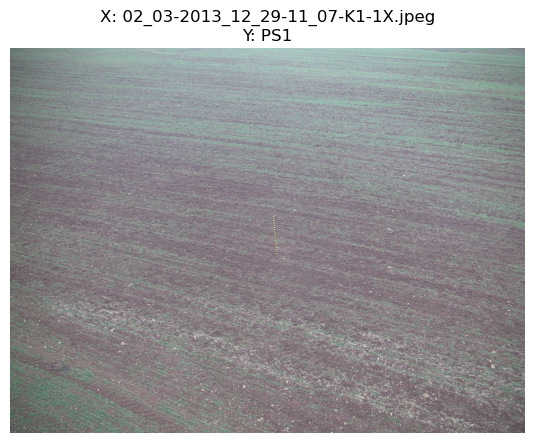

In [3]:

wf = WheatFramework(excel_path=excel_path, root_dir=data_path)

try:
    meta_df = wf.get_dataframe()
except Exception as e:
    print("Error loading data:", e)
    meta_df = pd.DataFrame()

if not meta_df.empty:
    X, y, folds = wf.get_splits(meta_df, n_splits=5)
    print(f"Total matched images: {len(X)}")

    # Print label mapping (encoded -> string label)
    classes = list(wf.le.classes_)
    mapping = {i: cls for i, cls in enumerate(classes)}
    print("\nLabel mapping (encoded -> label):")
    for k, v in mapping.items():
        print(k, ":", v)

    print("\nSample matched paths and labels:")
    display(meta_df[['path', 'label']].head(8))

    # Visual verification: display one random sample image and its label
    wf.get_sample(X, y)
else:
    print("No images matched. Review previous prints above for column mapping and search path.")


In [4]:
# Count images by group and stage
import pandas as pd

if 'meta_df' not in globals() or meta_df.empty:
    print("No `meta_df` available. Run the loader cell first (the one that creates `meta_df`).")
else:
    ct = pd.crosstab(meta_df['group_id'], meta_df['label'])
    ct['total'] = ct.sum(axis=1)
    ct = ct.sort_values('total', ascending=False)

    print('\nImages per group × stage (top 20 groups):')
    display(ct.head(20))

    print('\nStage totals:')
    stage_totals = ct.drop(columns=['total']).sum(axis=0).to_frame(name='count')
    display(stage_totals)



Images per group × stage (top 20 groups):


label,PS0,PS1,PS2,PS3,PS4,PS5,PS6,PS7,total
group_id,,,,,,,,,
7,92,12,15,6,14,21,12,28,200
6,22,20,34,28,47,4,18,16,189
10,31,24,18,28,35,13,25,14,188
1,20,19,37,15,47,12,8,23,181
9,101,17,15,5,15,8,20,0,181
2,12,37,21,24,22,9,19,30,174
3,19,22,26,40,26,14,11,16,174
4,7,37,5,18,36,15,13,31,162
8,45,14,17,4,39,21,3,17,160



Stage totals:


,count
label,
PS0,360
PS1,220
PS2,208
PS3,189
PS4,306
PS5,123
PS6,143
PS7,193


In [5]:
missing_data_per_station, missing_dates_for_stations = wf.get_stagewise_missing_data()



Stage: PS0

Stage: PS1

Stage: PS2

Stage: PS3


c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame in


Stage: PS4

Stage: PS5

Stage: PS6

Stage: PS7


c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame in

In [6]:

print("\nMissing data per station:")
##make a table with station, stage, and only missing count
print("Station\t", end="")
for i in range(1,9):
    print(f"\tPS{i}", end="")
print()
for station, stages in missing_data_per_station.items():
    print(f"{station}", end="")
    for stage, info in stages.items():
        print(f"\t{info['missing_count']}", end="")
    print()


Missing data per station:
Station		PS1	PS2	PS3	PS4	PS5	PS6	PS7	PS8
02.02_2014	2	1	0	0	9	4	3	12
02.03_2013	2	14	3	11	14	0	2	1
02.03_2014	1	0	3	14	4	6	2	6
02.04_2013	14	7	13	1	9	0	0	-1
02.05_2013	29	0	7	5	20	2	8	17
02.06_2016	3	14	2	1	0	10	2	-1
06.01_2013	21	13	0	0	15	2	0	-1
06.02_2013	10	2	8	14	5	0	15	3
06.02_2016	62	4	6	4	17	2	13	15
11.03_2016	18	4	2	0	4	8	0	1


In [7]:
missing_data_per_station["02.06_2016"]

{'PS0': {'missing_count': 3,
  'total_days': 25,
  'data_count': 22,
  'days': {'start': Timestamp('2016-11-12 00:00:00'),
   'end': Timestamp('2016-12-07 00:00:00'),
   'days': 25}},
 'PS1': {'missing_count': 14,
  'total_days': 34,
  'data_count': 20,
  'days': {'start': Timestamp('2016-12-07 00:00:00'),
   'end': Timestamp('2017-01-10 00:00:00'),
   'days': 34}},
 'PS2': {'missing_count': 2,
  'total_days': 36,
  'data_count': 34,
  'days': {'start': Timestamp('2017-01-10 00:00:00'),
   'end': Timestamp('2017-02-15 00:00:00'),
   'days': 36}},
 'PS3': {'missing_count': 1,
  'total_days': 29,
  'data_count': 28,
  'days': {'start': Timestamp('2017-02-15 00:00:00'),
   'end': Timestamp('2017-03-16 00:00:00'),
   'days': 29}},
 'PS4': {'missing_count': 0,
  'total_days': 47,
  'data_count': 47,
  'days': {'start': Timestamp('2017-03-16 00:00:00'),
   'end': Timestamp('2017-05-02 00:00:00'),
   'days': 47}},
 'PS5': {'missing_count': 10,
  'total_days': 14,
  'data_count': 4,
  'days': 

In [8]:
missing_dates_for_stations

{'02.02_2014': {Timestamp('2015-05-30 00:00:00'),
  Timestamp('2015-06-07 00:00:00'),
  Timestamp('2015-06-11 00:00:00'),
  Timestamp('2015-06-12 00:00:00'),
  Timestamp('2015-06-13 00:00:00'),
  Timestamp('2015-06-14 00:00:00'),
  Timestamp('2015-06-15 00:00:00'),
  Timestamp('2015-06-16 00:00:00'),
  Timestamp('2015-06-17 00:00:00'),
  Timestamp('2015-06-18 00:00:00'),
  Timestamp('2015-06-19 00:00:00'),
  Timestamp('2015-06-30 00:00:00'),
  Timestamp('2015-07-01 00:00:00')},
 '02.03_2013': {Timestamp('2014-05-30 00:00:00'),
  Timestamp('2014-06-12 00:00:00')},
 '02.03_2014': {Timestamp('2015-05-24 00:00:00'),
  Timestamp('2015-05-25 00:00:00'),
  Timestamp('2015-05-30 00:00:00'),
  Timestamp('2015-06-07 00:00:00'),
  Timestamp('2015-06-11 00:00:00'),
  Timestamp('2015-06-12 00:00:00'),
  Timestamp('2015-06-13 00:00:00')},
 '02.04_2013': {Timestamp('2014-03-17 00:00:00'),
  Timestamp('2014-03-18 00:00:00'),
  Timestamp('2014-03-19 00:00:00'),
  Timestamp('2014-03-20 00:00:00'),
  Tim

In [9]:
if 'meta_df' in globals() and not meta_df.empty:
    example_folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, random_state=42)
    print('\nGenerated', len(example_folds), 'folds. Sample sizes:')
    for i, (tr, te) in enumerate(example_folds, 1):
        print(f' Fold {i}: train_samples={len(tr)}, test_samples={len(te)}')
else:
    print('meta_df not found — run loader cell first to generate folds.')



Generated 5 folds. Sample sizes:
 Fold 1: train_samples=1361, test_samples=381
 Fold 2: train_samples=1380, test_samples=362
 Fold 3: train_samples=1387, test_samples=355
 Fold 4: train_samples=1406, test_samples=336
 Fold 5: train_samples=1387, test_samples=355


YOUR CODE HERE

In [10]:

# ---------------------
# EXAMPLES / TEMPLATES
# ---------------------

# Example: simple sklearn-like trainer function (for models with fit/predict APIs)
# def sklearn_trainer(train_df, test_df, fold_id):
#     # transform paths -> features as needed (e.g., load images and compute embeddings)
#     X_train, y_train = preprocess_paths_to_array(train_df['path'], train_df['label'])
#     X_test, y_test = preprocess_paths_to_array(test_df['path'], test_df['label'])
#     from sklearn.ensemble import RandomForestClassifier
#     model = RandomForestClassifier(n_estimators=100)
#     model.fit(X_train, y_train)
#     preds = model.predict(X_test)
#     # build predictions DataFrame
#     pred_df = pd.DataFrame({'path': test_df['path'], 'true': y_test, 'pred': preds})
#     metrics = {'accuracy': (pred_df['true'] == pred_df['pred']).mean()}
#     return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# Example: PyTorch training skeleton (user must implement dataset, dataloader, model, optimizer)
# def pytorch_trainer(train_df, test_df, fold_id):
#     import torch
#     # implement Dataset that loads images from `path` and returns tensors + labels
#     train_dataset = MyImageDataset(train_df)
#     test_dataset = MyImageDataset(test_df)
#     train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
#     test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32)
#     model = MyNet()
#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
#     loss_fn = torch.nn.CrossEntropyLoss()
#     # training loop ...
#     # after training produce preds and metrics
#     pred_df = pd.DataFrame({'path': test_df['path'], 'true': true_labels, 'pred': pred_labels})
#     metrics = {'accuracy': accuracy}
#     return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# Example: YOLO/Ultralytics style (pseudo)
# def yolov5_trainer(train_df, test_df, fold_id):
#     # prepare yaml/train.txt and yaml/val.txt listing image paths
#     # call ultralytics/train.py with appropriate args
#     # after training, load results and return predictions+metrics
#     pass

# ---------------------
# Quick sanity check: create a small set of folds and print counts


In [11]:
# --- VTMM2: DUAL VIT VARIANT (SEE COMMENTS MARKED CAPS BELOW FOR CHANGES VS VTMM) ---

TURKEY_COORDS = {
    1: (37.00, 35.32), 2: (37.76, 38.27), 3: (38.75, 30.55), 4: (39.71, 43.05), 5: (40.65, 35.83),
    6: (39.93, 32.85), 7: (36.89, 30.71), 8: (41.18, 41.81), 9: (37.84, 27.84), 10: (39.64, 27.88),
    11: (40.14, 29.97), 12: (38.88, 40.49), 13: (38.39, 42.10), 14: (40.73, 31.60), 15: (37.71, 30.28),
    16: (40.18, 29.06), 17: (40.15, 26.40), 18: (40.60, 33.61), 19: (40.54, 34.95), 20: (37.77, 29.08),
    21: (37.91, 40.23), 22: (41.67, 26.55), 23: (38.68, 39.22), 24: (39.74, 39.49), 25: (39.90, 41.27),
    26: (39.77, 30.52), 27: (37.06, 37.38), 28: (40.91, 38.38), 29: (40.45, 39.48), 30: (37.57, 43.73),
    31: (36.20, 36.15), 32: (37.76, 30.55), 33: (36.81, 34.64), 34: (41.00, 28.97), 35: (38.41, 27.14),
    36: (40.60, 43.09), 37: (41.37, 33.77), 38: (38.73, 35.48), 39: (41.73, 27.22), 40: (39.14, 34.16),
    41: (40.85, 29.88), 42: (37.87, 32.48), 43: (39.41, 29.98), 44: (38.35, 38.33), 45: (38.61, 27.42),
    46: (37.57, 36.92), 47: (37.31, 40.73), 48: (37.21, 28.36), 49: (38.73, 41.49), 50: (38.62, 34.71),
    51: (37.96, 34.67), 52: (40.98, 37.87), 53: (41.02, 40.51), 54: (40.77, 30.39), 55: (41.28, 36.33),
    56: (37.92, 41.94), 57: (42.02, 35.15), 58: (39.74, 37.01), 59: (40.97, 27.51), 60: (40.32, 36.55),
    61: (41.00, 39.71), 62: (39.10, 39.54), 63: (37.16, 38.79), 64: (38.67, 29.40), 65: (38.50, 43.37),
    66: (39.82, 34.80), 67: (41.45, 31.78), 68: (38.36, 34.02), 69: (40.26, 40.22), 70: (37.18, 33.21),
    71: (39.84, 33.51), 72: (37.88, 41.12), 73: (37.51, 42.45), 74: (41.63, 32.33), 75: (41.11, 42.70),
    76: (39.92, 44.04), 77: (40.65, 29.27), 78: (41.19, 32.62), 79: (36.71, 37.11), 80: (37.07, 36.24),
    81: (40.84, 31.15)
}
DEFAULT_COORD = (39.93, 32.85)

def prepare_advanced_features(df):
    df = df.copy()
    def extract_date(path):
        match = re.search(r'(\d{4}[_-]\d{2}[_-]\d{2})', str(path))
        if not match:
            return pd.NaT
        return pd.to_datetime(match.group(1).replace('-', '_'), format='%Y_%m_%d', errors='coerce')
    df['dt'] = df['path'].apply(extract_date)
    def get_agricultural_doy(date):
        if pd.isna(date):
            return np.nan
        planting_year = date.year if date.month >= 11 else date.year - 1
        nov_1st = pd.Timestamp(year=planting_year, month=11, day=1)
        return (date - nov_1st).days + 1
    df['agri_day_of_year'] = df['dt'].apply(get_agricultural_doy)
    df['date_missing'] = df['dt'].isna().astype(np.float32)
    df['plate_code'] = df['station_year'].astype(str).str.extract(r'^(\d{2})')[0].astype(float)
    def get_lat_lon(plate):
        if pd.isna(plate) or int(plate) not in TURKEY_COORDS:
            return DEFAULT_COORD
        return TURKEY_COORDS[int(plate)]
    coords = df['plate_code'].apply(get_lat_lon)
    df['latitude'] = [c[0] for c in coords]
    df['longitude'] = [c[1] for c in coords]
    return df


# TILE_TRAIN_MODE 'four_tile_avg' ==> TRAINING USES SAME 4-TILE STACK AS TEST + LOGIT AVG IN LOSS — CAPS: TRAIN TEST PROTOCOL ALIGNMENT
class MultimodalTiledDataset(Dataset):
    def __init__(self, df, label_map, transform=None, is_training=True, tile_train_mode="four_tile_avg"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_training = is_training
        self.label_map = label_map
        self.tile_train_mode = tile_train_mode

    def __len__(self):
        if self.is_training and self.tile_train_mode != "four_tile_avg":
            return len(self.df) * 4
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx // 4 if (self.is_training and self.tile_train_mode != "four_tile_avg") else idx]
        img = Image.open(row['path']).convert('RGB')
        w, h = img.size
        coords = [(0, 0, w // 2, h // 2), (w // 2, 0, w, h // 2), (0, h // 2, w // 2, h), (w // 2, h // 2, w, h)]
        if self.is_training:
            if self.tile_train_mode == "four_tile_avg":
                tiles = [img.crop(c) for c in coords]
                if self.transform:
                    tiles = [self.transform(t) for t in tiles]
                img_data = torch.stack(tiles)
            else:
                tile_pos = idx % 4
                img_data = img.crop(coords[tile_pos])
                if self.transform:
                    img_data = self.transform(img_data)
        else:
            tiles = [img.crop(c) for c in coords]
            if self.transform:
                tiles = [self.transform(t) for t in tiles]
            img_data = torch.stack(tiles)
        agri_day = row["agri_day_of_year"]
        lat_norm = row["latitude"]
        lon_norm = row["longitude"]
        meta_tensor = torch.tensor([agri_day, lat_norm, lon_norm], dtype=torch.float32)
        label_tensor = torch.tensor(self.label_map[row["label"]], dtype=torch.long)
        return img_data, meta_tensor, label_tensor


class MultimodalViTDual(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        from torchvision.models.vision_transformer import interpolate_embeddings
        weights = models.ViT_B_16_Weights.DEFAULT
        vit_num = 2
        self.vit_arr = nn.ModuleList([models.vit_b_16(weights=None, image_size=448) for _ in range(vit_num)])
        state_dict = weights.get_state_dict(progress=True)
        state_dict = interpolate_embeddings(image_size=448, patch_size=16, model_state=state_dict, reset_heads=True)
        vit_dim = self.vit_arr[0].heads.head.in_features
        for vit in self.vit_arr:
            vit.load_state_dict(state_dict, strict=False)
            vit.heads = nn.Identity()
        # CAPS STRONGER DROPOUT ON META_BRANCH — ANTI OVERFITTING
        self.meta_net = nn.Sequential(
            nn.Linear(3, 64),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(64, 128),
            nn.GELU(),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.38),
            nn.Linear(vit_num * vit_dim + 128, 256),
            nn.GELU(),
            nn.Dropout(0.28),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    def forward(self, img, meta):
        v_features = torch.cat([vit(img) for vit in self.vit_arr], dim=1)
        m_features = self.meta_net(meta)
        combined = torch.cat((v_features, m_features), dim=1)
        return self.classifier(combined)


def _flat_four_tiles(imgs):
    """(B,4,C,H,W) -> (B*4,C,H,W)"""
    b, k, c, h, w = imgs.shape
    return imgs.reshape(b * k, c, h, w)


def _repeat_meta(metas, k=4):
    """(B,D) -> (B*k,D)"""
    return metas.unsqueeze(1).expand(-1, k, -1).reshape(-1, metas.size(1))


def _dual_vit_backbone_params(model):
    ps = []
    for vit in model.vit_arr:
        ps += list(vit.parameters())
    return ps


def _dual_vit_head_params(model):
    return list(model.meta_net.parameters()) + list(model.classifier.parameters())


VTMM2_OUT = "vtmm2"
os.makedirs(VTMM2_OUT, exist_ok=True)


def multimodal_tiled_trainer(train_df, test_df, fold_id, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    img_size = config.get("img_size", 224)
    freeze_epochs = int(config.get("freeze_epochs", 2))
    base_lr = config["lr"]
    weight_decay = config.get("weight_decay", 0.08)
    label_smoothing = config.get("label_smoothing", 0.08)
    max_grad_norm = float(config.get("max_grad_norm", 1.0))
    unfreeze_lr_mult = float(config.get("unfreeze_lr_mult", 0.5))
    heads_lr_boost = float(config.get("heads_lr_boost", 2.0))

    tile_mode = config.get("tile_train_mode", "four_tile_avg")

    all_labels = sorted(train_df["label"].unique())
    label_map = {label: i for i, label in enumerate(all_labels)}
    inv_map = {v: k for k, v in label_map.items()}
    num_classes = len(all_labels)

    for df_ in [train_df, test_df]:
        df_["latitude"] = df_["latitude"].fillna(39.93)
        df_["longitude"] = df_["longitude"].fillna(32.85)
        df_["latitude"] = (df_["latitude"] - 36.20) / (41.73 - 36.20)
        df_["longitude"] = (df_["longitude"] - 26.39) / (43.73 - 26.39)

    # CAPS STRONGER AUGMENT — REGULARIZATION
    train_transform = transforms.Compose(
        [
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply(
                [transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.04)], p=0.55
            ),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.35))], p=0.12),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )

    test_transform = transforms.Compose(
        [
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )

    train_ds = MultimodalTiledDataset(train_df, label_map, train_transform, is_training=True, tile_train_mode=tile_mode)
    test_ds = MultimodalTiledDataset(test_df, label_map, test_transform, is_training=False)

    bs = config["batch_size"]
    # CAPS GPU MEMORY WARNING: four_tile_avg MULTIPLIES PATCHES PER BATCH BY THE NUMBER OF QUADRANTS (4×)
    if tile_mode == "four_tile_avg" and bs > 1 and not config.get("_batch_warn_dual", False):
        print("[VTMM2] CAPS MEMORY: TILE MODE four_tile_avg — USE SMALL batch_size WHEN GPU MEMORY IS LOW.")

    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

    model = MultimodalViTDual(num_classes).to(device)

    # CAPS PROGRESSIVE FREEZE: START WITH HEAD/meta_net ONLY THEN FINETUNE FULL NETWORK
    for p in _dual_vit_backbone_params(model):
        p.requires_grad = False

    backbone = _dual_vit_backbone_params(model)
    heads = _dual_vit_head_params(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    epochs = config["epochs"]

    eta_min_head = base_lr * heads_lr_boost * 0.05
    # CAPS SPLIT LR SCHEDULER: FREEZE PHASE (HEAD ONLY) COSINE THEN FULL NETWORK COSINE
    if freeze_epochs <= 0:
        for p in backbone:
            p.requires_grad = True
        lr_full = base_lr * unfreeze_lr_mult
        optimizer = optim.AdamW(model.parameters(), lr=lr_full, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(1, epochs), eta_min=max(lr_full * 0.02, base_lr * 1e-4)
        )
    else:
        optimizer = optim.AdamW(heads, lr=base_lr * heads_lr_boost, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(1, freeze_epochs), eta_min=eta_min_head
        )

    best_acc = 0.0
    best_pred_df = None
    best_model_state = None
    acc_not_increased_epoch_num = 0

    print(f"\n{'='*40}")
    print(f"[VTMM2 DUAL ViT] FOLD {fold_id} · freeze_epochs={freeze_epochs} · tile_train_mode={tile_mode}")
    print(f"{'='*40}")

    for epoch in range(epochs):
        if freeze_epochs > 0 and epoch == freeze_epochs:
            lr_full = base_lr * unfreeze_lr_mult
            print(f"CAPS FREEZE PHASE END epoch={epoch}: UNFREEZE ViT, NEW OPTIM LR={lr_full}")
            for p in backbone:
                p.requires_grad = True
            optimizer = optim.AdamW(model.parameters(), lr=lr_full, weight_decay=weight_decay)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=max(1, epochs - freeze_epochs),
                eta_min=max(lr_full * 0.02, base_lr * 1e-4),
            )

        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for imgs, metas, lbls in train_loader:
            metas = metas.to(device)
            lbls = lbls.to(device)
            imgs = imgs.to(device)
            optimizer.zero_grad()

            if imgs.dim() == 5:
                xf = _flat_four_tiles(imgs)
                mf = _repeat_meta(metas, k=imgs.size(1))
                outputs = model(xf, mf).view(imgs.size(0), imgs.size(1), -1).mean(dim=1)
            else:
                outputs = model(imgs, metas)

            loss = criterion(outputs, lbls)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += lbls.size(0)
            correct += predicted.eq(lbls).sum().item()

        scheduler.step()

        model.eval()
        all_preds, all_trues = [], []
        with torch.no_grad():
            for tiled_img, meta, lbl in test_loader:
                tiled_img = tiled_img.squeeze(0).to(device)
                meta = meta.to(device).squeeze(0) if meta.dim() > 1 else meta.to(device)
                meta_repeated = meta.repeat(4, 1)
                outputs = model(tiled_img, meta_repeated)
                avg_output = torch.mean(outputs, dim=0)
                pred = torch.argmax(avg_output).cpu().item()
                all_preds.append(pred)
                all_trues.append(lbl.item())

        fold_acc = float(np.mean(np.array(all_preds) == np.array(all_trues)))

        print(
            f"[VTMM2 dual] Epoch {epoch+1} train Loss: {running_loss / max(len(train_loader), 1):.4f} | train Acc: {100.0 * correct / max(total, 1):.2f}% | test Acc: {fold_acc:.4f}"
        )

        # import matplotlib.pyplot as plt
        # import seaborn as sns

        # plt.figure(figsize=(6, 5))
        # sns.heatmap(
        #     pd.crosstab(pd.Series(all_trues, name="True"), pd.Series(all_preds, name="Pred")),
        #     annot=True,
        #     fmt="d",
        #     cmap="Blues",
        # )
        # plt.title(f"[VTMM2 dual] Fold {fold_id} epoch {epoch+1}")
        # plt.tight_layout()
        # plt.savefig(os.path.join(VTMM2_OUT, f"fold_{fold_id}_dual_epoch_{epoch+1}_confusion_matrix.png"))
        # plt.close()

        if fold_acc <= best_acc:
            acc_not_increased_epoch_num += 1
        else:
            acc_not_increased_epoch_num = 0
            best_acc = fold_acc
            print(f"  🎉 New best test acc {best_acc:.4f}")
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_pred_df = pd.DataFrame(
                {
                    "path": test_df["path"].values,
                    "true": [inv_map[t] for t in all_trues],
                    "pred": [inv_map[p] for p in all_preds],
                }
            )

            model.load_state_dict(best_model_state)
            # CAPS SAVE CHECKPOINT WHEN TEST ACC >= 70% TO vtmm2/
            if best_acc >= float(config.get("save_acc_threshold", 0.70)):
                save_path = os.path.join(VTMM2_OUT, f"fold_{fold_id}_dual_acc{best_acc:.4f}.pth")
                save_model(model, save_path)
                print(f"  CAPS SAVED MODEL (TEST ACC >= threshold): {save_path}")
            model.train()

        if acc_not_increased_epoch_num > 0:
            print(f"  No test improvement for {acc_not_increased_epoch_num} epoch(s)")
        else:
            print("  Accuracy improved — reset patience")

        pat = config.get("patience", 3)
        if acc_not_increased_epoch_num >= pat:
            print(f"CAPS EARLY STOP: no gain {pat} epochs.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"[VTMM2 dual] ✅ FOLD {fold_id} BEST TEST ACCURACY: {best_acc:.4f}\n")
    return {"model": model, "predictions": best_pred_df, "metrics": {"accuracy": best_acc}}


# CAPS vtmm2 TRAINING HYPERPARAMETERS — LOWER LR, LABEL SMOOTHING, PATIENCE, FREEZE PHASE
multi_config = {
    "img_size": 448,
    "batch_size": 4,
    "lr": 1e-5,
    "epochs": 12,
    "weight_decay": 0.085,
    "label_smoothing": 0.08,
    "max_grad_norm": 1.0,
    "freeze_epochs": 2,
    "unfreeze_lr_mult": 0.45,
    "heads_lr_boost": 2.0,
    "tile_train_mode": "four_tile_avg",
    "save_acc_threshold": 0.60,
    "patience": 3,
}

meta_df_advanced = prepare_advanced_features(meta_df)

folds = generate_group_folds(meta_df_advanced, n_train=8, n_test=2, num_folds=5, group_col="group_id", random_state=42)
multi_metrics = []

for f_idx, (tr_idx, te_idx) in enumerate(folds):
    result = run_fold_with_trainer(
        meta_df=meta_df_advanced,
        train_idx=tr_idx,
        test_idx=te_idx,
        trainer_fn=lambda tr, te, fid: multimodal_tiled_trainer(tr, te, fid, multi_config),
        fold_id=f_idx + 1,
    )
    multi_metrics.append(result["metrics"]["accuracy"])

print("\n--- VTMM2 DUAL FINAL MEAN ACC ---")
print(np.mean(multi_metrics))



[VTMM2] CAPS MEMORY: TILE MODE four_tile_avg — USE SMALL batch_size WHEN GPU MEMORY IS LOW.


c:\Users\PC\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1355: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:35.)
  return t.to(



[VTMM2 DUAL ViT] FOLD 1 · freeze_epochs=2 · tile_train_mode=four_tile_avg
[VTMM2 dual] Epoch 1 train Loss: 1.9440 | train Acc: 27.26% | test Acc: 0.3780
  🎉 New best test acc 0.3780
  Accuracy improved — reset patience
[VTMM2 dual] Epoch 2 train Loss: 1.7502 | train Acc: 44.89% | test Acc: 0.5092
  🎉 New best test acc 0.5092
  Accuracy improved — reset patience
CAPS FREEZE PHASE END epoch=2: UNFREEZE ViT, NEW OPTIM LR=4.5e-06
[VTMM2 dual] Epoch 3 train Loss: 1.4025 | train Acc: 56.50% | test Acc: 0.6325
  🎉 New best test acc 0.6325
  CAPS SAVED MODEL (TEST ACC >= threshold): vtmm2\fold_1_dual_acc0.6325.pth
  Accuracy improved — reset patience


KeyboardInterrupt: 

both 1x and 10X image 2 vit: 61%
5 vit: only one fold: 63%
2 vit: 67%

In [ ]:
# --- VTMM2: SINGLE ViT VARIANT (CAPS SAME REGULARIZATION IDEA AS CELL ABOVE) ---

TURKEY_COORDS = {
    1: (37.00, 35.32), 2: (37.76, 38.27), 3: (38.75, 30.55), 4: (39.71, 43.05), 5: (40.65, 35.83),
    6: (39.93, 32.85), 7: (36.89, 30.71), 8: (41.18, 41.81), 9: (37.84, 27.84), 10: (39.64, 27.88),
    11: (40.14, 29.97), 12: (38.88, 40.49), 13: (38.39, 42.10), 14: (40.73, 31.60), 15: (37.71, 30.28),
    16: (40.18, 29.06), 17: (40.15, 26.40), 18: (40.60, 33.61), 19: (40.54, 34.95), 20: (37.77, 29.08),
    21: (37.91, 40.23), 22: (41.67, 26.55), 23: (38.68, 39.22), 24: (39.74, 39.49), 25: (39.90, 41.27),
    26: (39.77, 30.52), 27: (37.06, 37.38), 28: (40.91, 38.38), 29: (40.45, 39.48), 30: (37.57, 43.73),
    31: (36.20, 36.15), 32: (37.76, 30.55), 33: (36.81, 34.64), 34: (41.00, 28.97), 35: (38.41, 27.14),
    36: (40.60, 43.09), 37: (41.37, 33.77), 38: (38.73, 35.48), 39: (41.73, 27.22), 40: (39.14, 34.16),
    41: (40.85, 29.88), 42: (37.87, 32.48), 43: (39.41, 29.98), 44: (38.35, 38.33), 45: (38.61, 27.42),
    46: (37.57, 36.92), 47: (37.31, 40.73), 48: (37.21, 28.36), 49: (38.73, 41.49), 50: (38.62, 34.71),
    51: (37.96, 34.67), 52: (40.98, 37.87), 53: (41.02, 40.51), 54: (40.77, 30.39), 55: (41.28, 36.33),
    56: (37.92, 41.94), 57: (42.02, 35.15), 58: (39.74, 37.01), 59: (40.97, 27.51), 60: (40.32, 36.55),
    61: (41.00, 39.71), 62: (39.10, 39.54), 63: (37.16, 38.79), 64: (38.67, 29.40), 65: (38.50, 43.37),
    66: (39.82, 34.80), 67: (41.45, 31.78), 68: (38.36, 34.02), 69: (40.26, 40.22), 70: (37.18, 33.21),
    71: (39.84, 33.51), 72: (37.88, 41.12), 73: (37.51, 42.45), 74: (41.63, 32.33), 75: (41.11, 42.70),
    76: (39.92, 44.04), 77: (40.65, 29.27), 78: (41.19, 32.62), 79: (36.71, 37.11), 80: (37.07, 36.24),
    81: (40.84, 31.15)
}
DEFAULT_COORD = (39.93, 32.85)

def prepare_advanced_features(df):
    df = df.copy()
    def extract_date(path):
        match = re.search(r'(\d{4}[_-]\d{2}[_-]\d{2})', str(path))
        if not match:
            return pd.NaT
        return pd.to_datetime(match.group(1).replace('-', '_'), format='%Y_%m_%d', errors='coerce')
    df['dt'] = df['path'].apply(extract_date)
    def get_agricultural_doy(date):
        if pd.isna(date):
            return np.nan
        planting_year = date.year if date.month >= 11 else date.year - 1
        nov_1st = pd.Timestamp(year=planting_year, month=11, day=1)
        return (date - nov_1st).days + 1
    df['agri_day_of_year'] = df['dt'].apply(get_agricultural_doy)
    df['date_missing'] = df['dt'].isna().astype(np.float32)
    df['plate_code'] = df['station_year'].astype(str).str.extract(r'^(\d{2})')[0].astype(float)
    def get_lat_lon(plate):
        if pd.isna(plate) or int(plate) not in TURKEY_COORDS:
            return DEFAULT_COORD
        return TURKEY_COORDS[int(plate)]
    coords = df['plate_code'].apply(get_lat_lon)
    df['latitude'] = [c[0] for c in coords]
    df['longitude'] = [c[1] for c in coords]
    return df


class MultimodalTiledDataset(Dataset):
    def __init__(self, df, label_map, transform=None, is_training=True, tile_train_mode="four_tile_avg"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_training = is_training
        self.label_map = label_map
        self.tile_train_mode = tile_train_mode

    def __len__(self):
        if self.is_training and self.tile_train_mode != "four_tile_avg":
            return len(self.df) * 4
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx // 4 if (self.is_training and self.tile_train_mode != "four_tile_avg") else idx]
        img = Image.open(row['path']).convert('RGB')
        w, h = img.size
        coords = [(0, 0, w // 2, h // 2), (w // 2, 0, w, h // 2), (0, h // 2, w // 2, h), (w // 2, h // 2, w, h)]
        if self.is_training:
            if self.tile_train_mode == "four_tile_avg":
                tiles = [img.crop(c) for c in coords]
                if self.transform:
                    tiles = [self.transform(t) for t in tiles]
                img_data = torch.stack(tiles)
            else:
                tile_pos = idx % 4
                img_data = img.crop(coords[tile_pos])
                if self.transform:
                    img_data = self.transform(img_data)
        else:
            tiles = [img.crop(c) for c in coords]
            if self.transform:
                tiles = [self.transform(t) for t in tiles]
            img_data = torch.stack(tiles)
        agri_day = row["agri_day_of_year"]
        meta_tensor = torch.tensor([agri_day, row["latitude"], row["longitude"]], dtype=torch.float32)
        label_tensor = torch.tensor(self.label_map[row["label"]], dtype=torch.long)
        return img_data, meta_tensor, label_tensor


class MultimodalViTSingle(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        from torchvision.models.vision_transformer import interpolate_embeddings
        weights = models.ViT_B_16_Weights.DEFAULT
        self.vit = models.vit_b_16(weights=None, image_size=448)
        sd = weights.get_state_dict(progress=True)
        sd = interpolate_embeddings(image_size=448, patch_size=16, model_state=sd, reset_heads=True)
        self.vit.load_state_dict(sd, strict=False)
        vit_dim = self.vit.heads.head.in_features
        self.vit.heads = nn.Identity()
        self.meta_net = nn.Sequential(
            nn.Linear(3, 64),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(64, 128),
            nn.GELU(),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.38),
            nn.Linear(vit_dim + 128, 256),
            nn.GELU(),
            nn.Dropout(0.28),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    def forward(self, img, meta):
        combined = torch.cat((self.vit(img), self.meta_net(meta)), dim=1)
        return self.classifier(combined)


def _flat_four_tiles(imgs):
    b, k, c, h, w = imgs.shape
    return imgs.reshape(b * k, c, h, w)


def _repeat_meta(metas, k=4):
    return metas.unsqueeze(1).expand(-1, k, -1).reshape(-1, metas.size(1))


VTMM2_OUT = "vtmm2"
os.makedirs(VTMM2_OUT, exist_ok=True)


def multimodal_tiled_trainer(train_df, test_df, fold_id, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    img_size = config.get("img_size", 224)
    freeze_epochs = int(config.get("freeze_epochs", 2))
    base_lr = config["lr"]
    weight_decay = config.get("weight_decay", 0.08)

    tile_mode = config.get("tile_train_mode", "four_tile_avg")

    all_labels = sorted(train_df["label"].unique())
    label_map = {label: i for i, label in enumerate(all_labels)}
    inv_map = {v: k for k, v in label_map.items()}
    num_classes = len(all_labels)

    for df_ in [train_df, test_df]:
        df_["latitude"] = df_["latitude"].fillna(39.93)
        df_["longitude"] = df_["longitude"].fillna(32.85)
        df_["latitude"] = (df_["latitude"] - 36.20) / (41.73 - 36.20)
        df_["longitude"] = (df_["longitude"] - 26.39) / (43.73 - 26.39)

    train_transform = transforms.Compose(
        [
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply(
                [transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.04)], p=0.55
            ),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.35))], p=0.12),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )
    test_transform = transforms.Compose(
        [
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )

    train_loader = DataLoader(
        MultimodalTiledDataset(train_df, label_map, train_transform, True, tile_mode),
        batch_size=config["batch_size"],
        shuffle=True,
    )
    test_loader = DataLoader(MultimodalTiledDataset(test_df, label_map, test_transform, False), batch_size=1, shuffle=False)

    model = MultimodalViTSingle(num_classes).to(device)

    backbone = list(model.vit.parameters())
    heads = list(model.meta_net.parameters()) + list(model.classifier.parameters())
    for p in backbone:
        p.requires_grad = False

    criterion = nn.CrossEntropyLoss(label_smoothing=config.get("label_smoothing", 0.08))

    epochs = config["epochs"]
    heads_boost = float(config.get("heads_lr_boost", 2.0))
    ulr = float(config.get("unfreeze_lr_mult", 0.45))
    eta_min_head = base_lr * heads_boost * 0.05
    # CAPS MATCH DUAL SCHEDULER BEHAVIOR: SHORT COSINE WHILE HEAD-ONLY THEN FULL NETWORK
    if freeze_epochs <= 0:
        for p in backbone:
            p.requires_grad = True
        lr_full = base_lr * ulr
        optimizer = optim.AdamW(model.parameters(), lr=lr_full, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(1, epochs), eta_min=max(lr_full * 0.02, base_lr * 1e-4)
        )
    else:
        optimizer = optim.AdamW(heads, lr=base_lr * heads_boost, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(1, freeze_epochs), eta_min=eta_min_head
        )

    best_acc = 0.0
    best_pred_df = None
    best_model_state = None
    acc_not_increased_epoch_num = 0

    print(f"\n{'='*40}\n[VTMM2 SINGLE ViT] fold {fold_id} tile_train_mode={tile_mode}\n{'='*40}")

    for epoch in range(epochs):
        if freeze_epochs > 0 and epoch == freeze_epochs:
            lr_full = base_lr * ulr
            print(f"CAPS UNFREEZE ViT SINGLE · NEW LR {lr_full}")
            for p in backbone:
                p.requires_grad = True
            optimizer = optim.AdamW(model.parameters(), lr=lr_full, weight_decay=weight_decay)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=max(1, epochs - freeze_epochs), eta_min=max(lr_full * 0.02, base_lr * 1e-4)
            )

        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for imgs, metas, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            metas = metas.to(device)
            optimizer.zero_grad()
            if imgs.dim() == 5:
                xf, mf = _flat_four_tiles(imgs), _repeat_meta(metas, k=imgs.size(1))
                out = model(xf, mf).view(imgs.size(0), imgs.size(1), -1).mean(dim=1)
            else:
                out = model(imgs, metas)
            loss = criterion(out, lbls)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(config.get("max_grad_norm", 1.0)))
            optimizer.step()
            running_loss += loss.item()
            _, pred = out.max(1)
            total += lbls.size(0)
            correct += pred.eq(lbls).sum().item()

        scheduler.step()

        model.eval()
        all_preds, all_trues = [], []
        with torch.no_grad():
            for tiled_img, meta, lbl in test_loader:
                tiled_img = tiled_img.squeeze(0).to(device)
                meta = meta.to(device)
                meta_r = meta.repeat(4, 1)
                out = model(tiled_img, meta_r)
                all_preds.append(torch.argmax(torch.mean(out, dim=0)).cpu().item())
                all_trues.append(lbl.item())

        fold_acc = float(np.mean(np.array(all_preds) == np.array(all_trues)))
        print(
            f"[VTMM2 single] Epoch {epoch+1} Loss {running_loss/max(len(train_loader),1):.4f} trainAcc {100*correct/max(total,1):.2f}% test {fold_acc:.4f}"
        )

        import matplotlib.pyplot as plt
        import seaborn as sns

        plt.figure(figsize=(6, 5))
        sns.heatmap(pd.crosstab(pd.Series(all_trues, name="True"), pd.Series(all_preds, name="Pred")), annot=True, fmt="d", cmap="Blues")
        plt.title(f"VTMM2 single Fold {fold_id} Epoch {epoch+1}")
        plt.tight_layout()
        plt.savefig(os.path.join(VTMM2_OUT, f"fold_{fold_id}_single_epoch_{epoch+1}_confusion_matrix.png"))
        plt.close()

        if fold_acc <= best_acc:
            acc_not_increased_epoch_num += 1
        else:
            acc_not_increased_epoch_num = 0
            best_acc = fold_acc
            print(f"  best {best_acc:.4f}")
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_pred_df = pd.DataFrame(
                {
                    "path": test_df["path"].values,
                    "true": [inv_map[t] for t in all_trues],
                    "pred": [inv_map[p] for p in all_preds],
                }
            )

            model.load_state_dict(best_model_state)
            if best_acc >= float(config.get("save_acc_threshold", 0.70)):
                sp = os.path.join(VTMM2_OUT, f"fold_{fold_id}_single_acc{best_acc:.4f}.pth")
                save_model(model, sp)
                print(f"CAPS SAVED SINGLE ViT MODEL (TEST ACC >= threshold): {sp}")
            model.train()

        if acc_not_increased_epoch_num >= int(config.get("patience", 3)):
            print("CAPS EARLY STOP")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    print(f"[VTMM2 single] FOLD {fold_id} BEST {best_acc:.4f}")
    return {"model": model, "predictions": best_pred_df, "metrics": {"accuracy": best_acc}}


multi_config = {
    "img_size": 448,
    "batch_size": 4,
    "lr": 1e-5,
    "epochs": 12,
    "weight_decay": 0.085,
    "label_smoothing": 0.08,
    "freeze_epochs": 2,
    "unfreeze_lr_mult": 0.45,
    "heads_lr_boost": 2.0,
    "tile_train_mode": "four_tile_avg",
    "save_acc_threshold": 0.70,
    "patience": 3,
}

meta_df_advanced = prepare_advanced_features(meta_df)

folds = generate_group_folds(meta_df_advanced, n_train=8, n_test=2, num_folds=5, group_col="group_id", random_state=42)
multi_metrics = []

for f_idx, (tr_idx, te_idx) in enumerate(folds):
    result = run_fold_with_trainer(
        meta_df=meta_df_advanced,
        train_idx=tr_idx,
        test_idx=te_idx,
        trainer_fn=lambda tr, te, fid: multimodal_tiled_trainer(tr, te, fid, multi_config),
        fold_id=f_idx + 1,
    )
    multi_metrics.append(result["metrics"]["accuracy"])

print("\n------ VTMM2 SINGLE FINAL MEAN ACC ------")
print(np.mean(multi_metrics))




[VTMM2 SINGLE ViT] fold 1 tile_train_mode=four_tile_avg
[VTMM2 single] Epoch 1 Loss 2.0575 trainAcc 23.73% test 0.2546
  best 0.2546
[VTMM2 single] Epoch 2 Loss 1.8998 trainAcc 29.54% test 0.2441
CAPS UNFREEZE ViT SINGLE · NEW LR 4.5e-06
[VTMM2 single] Epoch 3 Loss 1.6677 trainAcc 46.95% test 0.5407
  best 0.5407
[VTMM2 single] Epoch 4 Loss 1.3777 trainAcc 62.82% test 0.6194
  best 0.6194
[VTMM2 single] Epoch 5 Loss 1.1902 trainAcc 72.08% test 0.6640
  best 0.6640
[VTMM2 single] Epoch 6 Loss 1.0354 trainAcc 80.24% test 0.6824
  best 0.6824
[VTMM2 single] Epoch 7 Loss 0.9483 trainAcc 81.34% test 0.6115
[VTMM2 single] Epoch 8 Loss 0.8562 trainAcc 84.72% test 0.5381
[VTMM2 single] Epoch 9 Loss 0.8099 trainAcc 86.55% test 0.6089
CAPS EARLY STOP
[VTMM2 single] FOLD 1 BEST 0.6824

[VTMM2 SINGLE ViT] fold 2 tile_train_mode=four_tile_avg
[VTMM2 single] Epoch 1 Loss 2.0689 trainAcc 19.78% test 0.3011
  best 0.3011
[VTMM2 single] Epoch 2 Loss 1.8985 trainAcc 33.33% test 0.3315
  best 0.3315
CAP